In [99]:
import pandas as pd
import matplotlib.pyplot as plt

In [100]:
df = pd.read_csv(r"C:\Users\Junayed\nyc-311-resolution-time-analysis\data\clean\311_jan_week1_clean.csv")

### Chart 1: Top 10 Slowest Complaint Types (Median Turnaround)

Visualizing typical resolution latency across the slowest municipal complaint types, filtered to categories with meaningful operational volume ($N \ge 20$ requests):

* **Chart Construction:** A horizontal bar chart provides readability for long administrative titles without label crowding. Each bar displays its **Median Resolution Days** and total intake volume (**$N$**).
* **Key Observations:**
  * Multi-month resolution times are heavily concentrated in regulatory, airspace, and administrative casework (such as `Noise - Helicopter` and TLC taxi/FHV summonses).
  * Structural building maintenance, facility inspections, and consumer affairs cases follow, confirming that long-tail turnaround reflects procedural and regulatory complexity rather than high request volume.

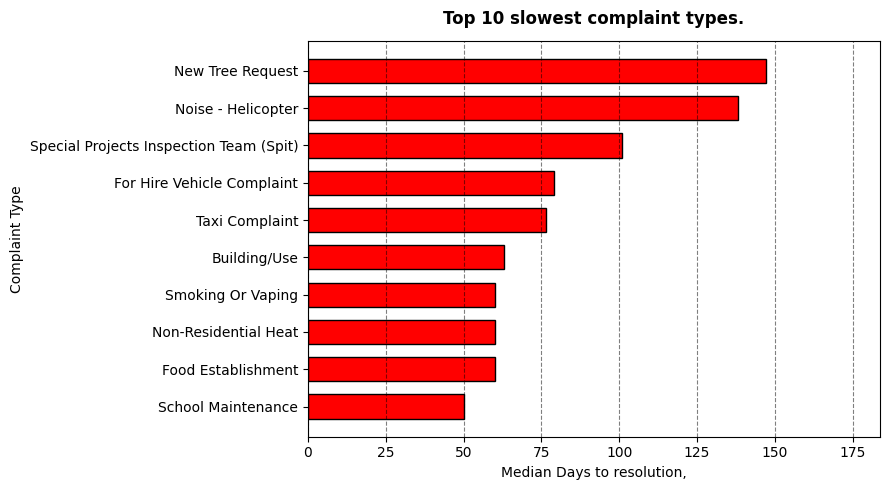

In [113]:
complaint_stats = df.groupby("Complaint_Type")["Resolution_Days"].agg(
    Median = "median",
    Ticket_Count = "count"
)

top_10_slowest = (
    complaint_stats[complaint_stats["Ticket_Count"] >=20]
    .sort_values(by="Median", ascending=True)
).tail(10)

# top_10_slowest - run for to check the dataset

fig, ax = plt.subplots(figsize=(9,5))

bars = ax.barh(
    top_10_slowest.index,
    top_10_slowest["Median"],
    color="red",
    edgecolor="black",
    height=0.65
)


ax.set_title(
    "Top 10 slowest complaint types.",
    fontsize= 12,
    fontweight = "bold",
    pad = 12
)

ax.set_xlabel(
    "Median Days to resolution,",
    fontsize = 10
)

ax.set_ylabel(
    "Complaint Type",
    fontsize = 10
)

ax.set_xlim(
    0, top_10_slowest["Median"].max() *1.25
)

ax.grid(axis="x", linestyle='--', color = "black", alpha=0.5)

plt.tight_layout()
plt.show()

### Chart 2: Resolution Time Distribution (Histogram)

Plotting in EDA frequently consists of Histograms, Box plot, Scatter plot and many more. For this analysis, a dual-panel histogram is used to show the frequency of occurrence of variables in an interval. Both panels utilize a logarithmic scale on the y-axis to ensure that smaller ticket volumes remain visible next to massive spikes.

* **The 30-Day Window (Left Panel):** By using a log scale, we can clearly see the massive initial spike of same-day resolutions (tens of thousands of tickets) while still making out the daily decay, which stabilizes into the hundreds as we approach the 30-day mark.
* **The Long Tail (Right Panel):** The logarithmic scale highlights the extreme outliers in the broader dataset. While most tickets clear quickly, a persistent volume of complaints stretches past the 100-day and 365-day thresholds, maxing out at over 600 days.
* **Takeaway:** The resolution data is heavily right-skewed. The city handles rapid requests in exceptionally high volumes but maintains a long-term backlog of stubborn, multi-month operational tasks that would be nearly invisible on a standard linear chart.

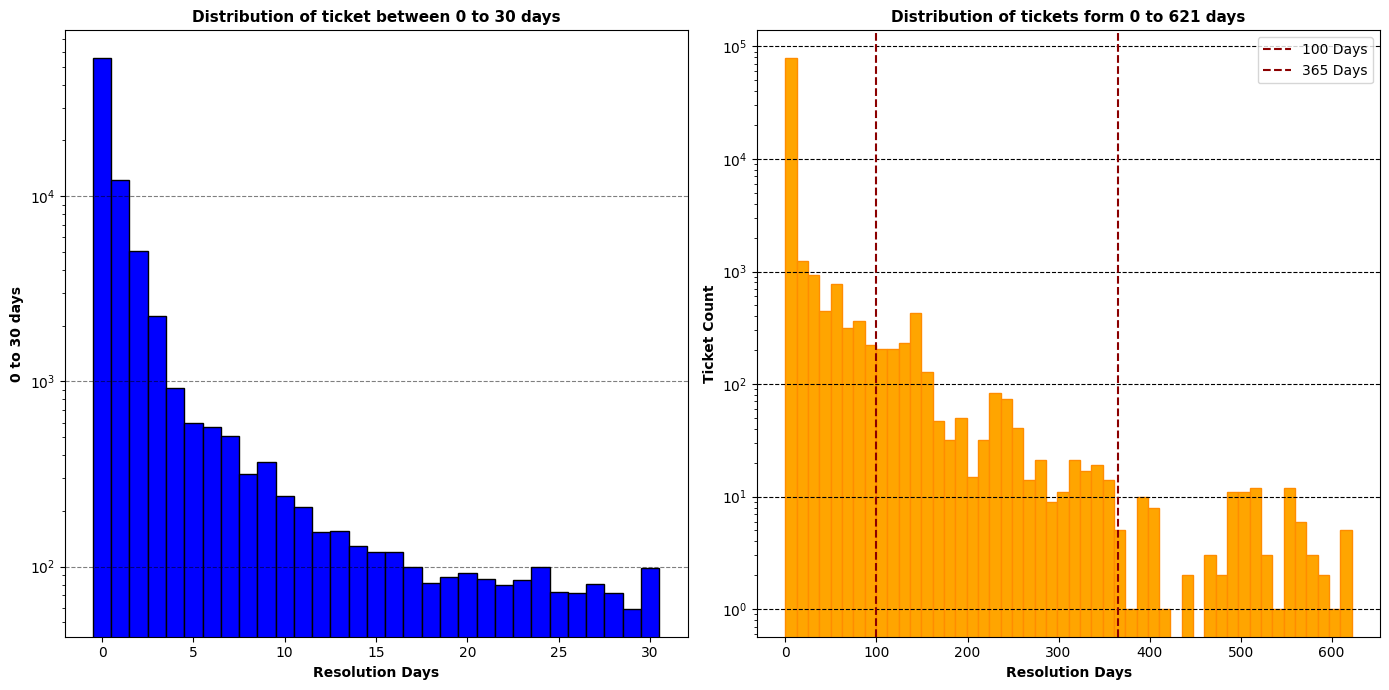

In [102]:
fig, axes = plt.subplots(1,2, figsize=(14,7))

# Plot 1
zoomed_data = df[df["Resolution_Days"] <= 30]["Resolution_Days"]

axes[0].hist(
    zoomed_data,
    color ="blue",
    edgecolor= "black",
    bins = range(0,32),
    align = "left",
    log = True
)

axes[0].set_title(
    "Distribution of ticket between 0 to 30 days",
    fontweight = "bold",
    fontsize = 11
)
axes[0].set_xlabel(
    "Resolution Days",
    color = "black",
    fontweight = "bold"
    )
axes[0].set_ylabel(
    "0 to 30 days",
    color = "black",
    fontweight = "bold"
    )
axes[0].grid(axis="y", color = "black", linestyle="--", alpha=0.5)

# Plot 2

axes[1].hist(
    df["Resolution_Days"],
    bins=50,
    color="orange",
    edgecolor = "darkorange",
    log=True
)

axes[1].set_title(
    "Distribution of tickets form 0 to 621 days",
    fontweight = "bold",
    fontsize=11
    )

axes[1].axvline(
    100, color="darkred", 
    linestyle ="--", 
    linewidth="1.5",
    label = "100 Days"
)

axes[1].axvline(
    365, color="darkred", 
    linestyle ="--", 
    linewidth="1.5",
    label = "365 Days"
)

axes[1].set_xlabel(
    "Resolution Days",
    color = "black",
    fontweight = "bold"
    )
axes[1].set_ylabel(
    "Ticket Count",
    color = "black",
    fontweight = "bold"
    )
axes[1].grid(axis='y', color = "black", linestyle="--", alpha=1)
axes[1].legend()
plt.tight_layout()
plt.show()

### Geographic Analysis: Request Volume vs. Mean Resolution Time

Comparing ticket volume directly against average resolution times across the five boroughs highlights an operational paradox between municipal workload and processing speed.

* **Volume Disparity (Right Panel - Number of Requests):**
  * **Bronx:** ~37,500 requests
  * **Brooklyn:** ~18,800 requests
  * **Queens:** ~14,200 requests
  * **Manhattan:** ~12,100 requests
  * **Staten Island:** ~2,100 requests

* **Turnaround Inversion (Left Panel - Mean Days to Resolution):**
  * **Manhattan:** ~13.7 days
  * **Queens:** ~9.9 days
  * **Staten Island:** ~8.7 days
  * **Brooklyn:** ~7.4 days
  * **Bronx:** ~2.6 days

* **Operational Implication:** High ticket volume does not create systemic resolution bottlenecks. The Bronx processes the highest number of requests (~37,500) while maintaining the fastest average resolution time (~2.6 days). Conversely, Manhattan receives fewer requests (~12,100) yet averages the slowest resolution time (~13.7 days). This indicates that geographic location and total volume are not the primary drivers of resolution delays.

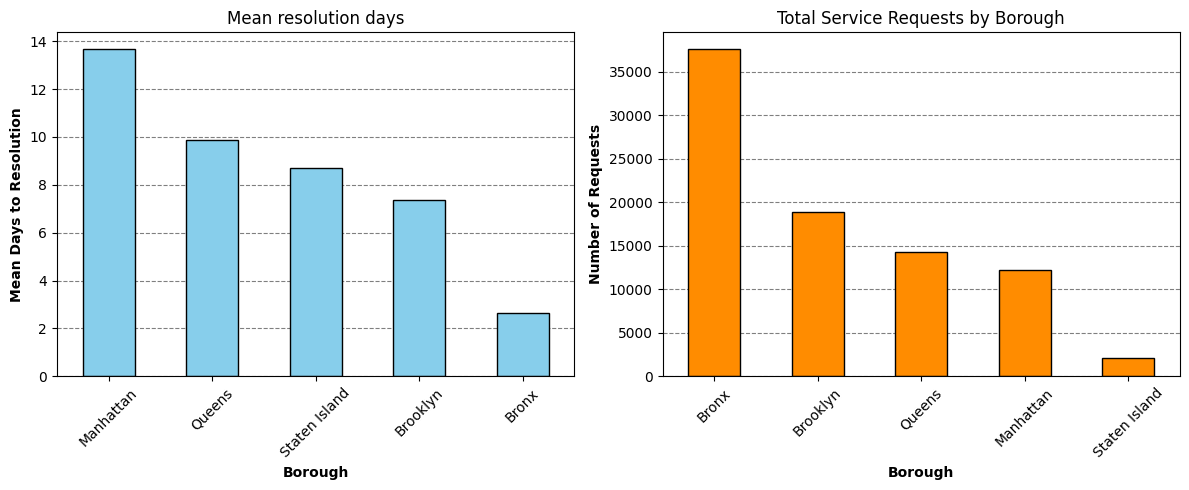

In [103]:
fig, axess = plt.subplots(1, 2, figsize=(12, 5))

#Plot 1
borough_mean1 = df.groupby("Borough")["Resolution_Days"].mean().sort_values(ascending=False)

borough_mean1.plot(
    kind = "bar",
    color = "skyblue",
    edgecolor = "black",
    ax = axess[0]
)

axess[0].set_xlabel(
    "Borough",
    color = "black",
    fontweight = "bold"
)

axess[0].set_ylabel(
    "Mean Days to Resolution",
    color = "black",
    fontweight = "bold"
)

axess[0].set_title(
    "Mean resolution days"
)

axess[0].tick_params(axis='x', rotation = 45)
axess[0].grid(axis = "y",color = "black", linestyle = "--", alpha = 0.5)
axess[0].set_axisbelow(True)

#Plot 2

borough_volume = df["Borough"].value_counts()

borough_volume.plot(
    kind = "bar",
    color = "darkorange",
    edgecolor = "black",
    ax = axess[1]
)

axess[1].set_title(
    "Total Service Requests by Borough"
)
axess[1].set_xlabel(
    "Borough",
    color = "black",
    fontweight = "bold"
)
axess[1].set_ylabel(
    "Number of Requests",
    color = "black",
    fontweight = "bold"
)
axess[1].tick_params(
    axis = "x", rotation = 45
)
axess[1].grid(axis = "y", color = "black", linestyle = "--", alpha = 0.5)
axess[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

### Operational Variance: Top 10 Slowest vs. Top 10 Fastest Complaints

Examining the median turnaround times across specific request types exposes an extreme divergence in operational velocity, showing that resolution time is strictly dictated by the task's operational complexity rather than municipal geography.

* **Top 10 Slowest Complaints (Left Panel - Median Days):**
  * **Uprooted Stump:** ~175 days
  * **New Tree Request:** ~147 days
  * **Noise - Helicopter:** ~139 days
  * **Special Projects Inspection Team (Spit):** ~101 days
  * **Green Taxi Complaint:** ~97 days
  * **Lot Condition:** ~93 days
  * **For Hire Vehicle Complaint:** ~79 days
  * **Taxi Complaint:** ~77 days
  * **Bench:** ~70 days
  * **Building/Use:** ~63 days

* **Top 10 Fastest Complaints (Right Panel - Median Hours):**
  * **Non-Emergency Police Matter:** ~1.18 hrs
  * **Drinking:** ~1.11 hrs
  * **Noise - Vehicle:** ~0.88 hrs
  * **Noise - House Of Worship:** ~0.84 hrs
  * **Noise - Street/Sidewalk:** ~0.76 hrs
  * **Noise - Commercial:** ~0.71 hrs
  * **Noise - Park:** ~0.57 hrs
  * **Drug Activity:** ~0.55 hrs
  * **Illegal Fireworks:** ~0.54 hrs
  * **Traffic:** ~0.48 hrs

* **Operational Insight:** Filtering out automated batch closures reveals that the fastest 10 complaint types—primarily quality-of-life and routine enforcement issues handled by the NYPD—consistently achieve real-world field turnaround times in **under 1.2 hours**. In contrast, complex infrastructural and inter-agency issues (such as Parks & Recreation tree maintenance or TLC investigations) span **60 to 175 days**. This multi-magnitude gap confirms that agency jurisdiction and service mandates are the primary drivers of 311 resolution timelines.

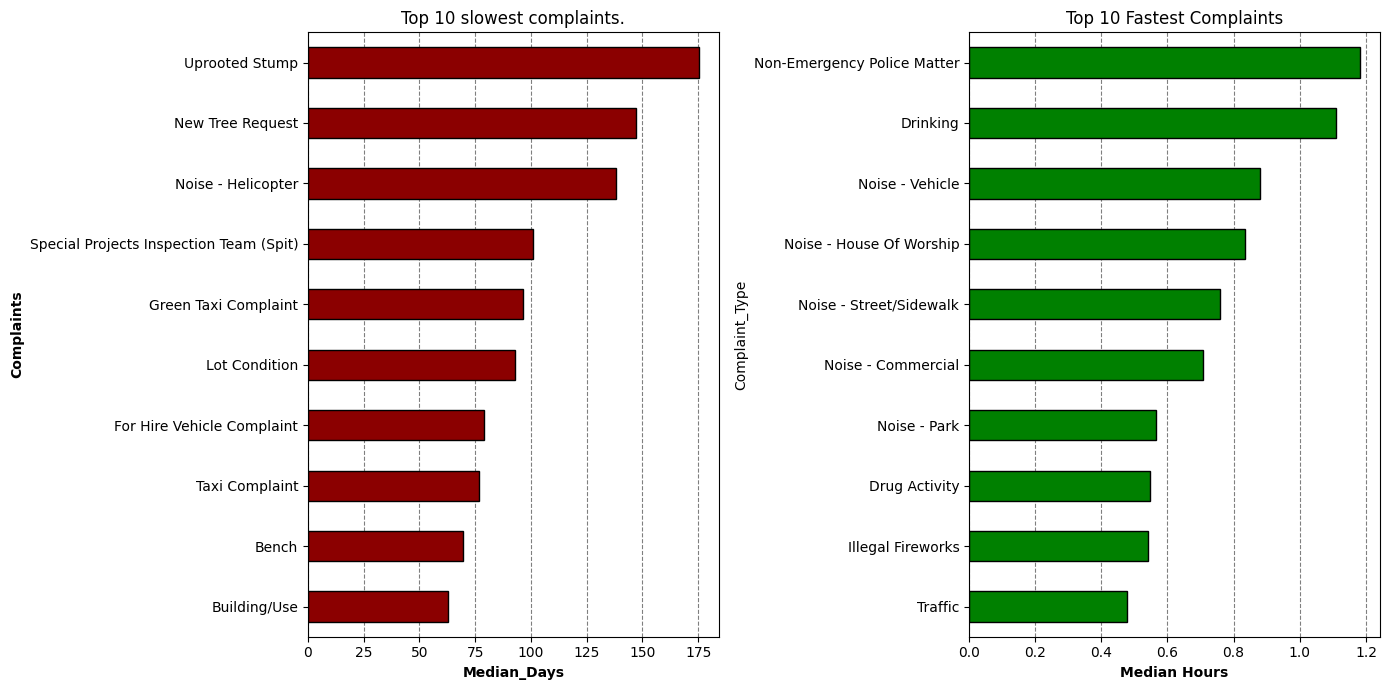

In [110]:
fig, axes = plt.subplots(1,2,figsize=(14,7))

# Plot 1 with slowest complaint resolution
slowest_10_comp = df.groupby("Complaint_Type")["Resolution_Days"].median().sort_values(ascending=False).head(10).sort_values(ascending=True)
slowest_10_comp.plot(
    kind = "barh",
    color = "darkred",
    edgecolor = "black",
    ax = axes[0]
)
axes[0].set_xlabel(
    "Median_Days",
    color = "black",
    fontweight = "bold"
)

axes[0].set_ylabel(
    "Complaints",
    color = "black",
    fontweight = "bold"
)

axes[0].set_title(
    "Top 10 slowest complaints."
)

axes[0].grid(axis = "x",color = "black", linestyle = "--", alpha = 0.5)
axes[0].set_axisbelow(True)


# Plot 2 with fastest complaint resolution
# Filter to ensure we only look at complaints with a decent sample size (e.g., > 20 tickets)
clean_df = df[(df["Created_Date"] != df["Closed_Date"]) & (df["Closed_Date"].notna())].copy()

clean_df["Exact_Resolution_Hours"] = (
    pd.to_datetime(clean_df["Closed_Date"]) - pd.to_datetime(clean_df["Created_Date"])
).dt.total_seconds() / 3600


complaint_counts = clean_df.groupby("Complaint_Type")["Exact_Resolution_Hours"].count()
valid_complaints = complaint_counts[complaint_counts > 20].index


fastest_10_comp = (
    clean_df[clean_df["Complaint_Type"].isin(valid_complaints)]
    .groupby("Complaint_Type")["Exact_Resolution_Hours"]
    .median()
    .sort_values(ascending=True)
    .head(10)
    .sort_values(ascending=True) 
)

fastest_10_comp.plot(
    kind = "barh",
    color = "green",
    edgecolor = "black"
)

axes[1].set_xlabel("Median Hours", color="black", fontweight="bold")
axes[1].set_title("Top 10 Fastest Complaints")
axes[1].grid(axis="x", color="black", linestyle="--", alpha=0.5)
axes[1].set_axisbelow(True)


# -------------------------------------------------------------
# Final Rendering
# -------------------------------------------------------------
plt.tight_layout()
plt.show()



### Chart 5: Distribution Analysis (Geography vs. Operational Mandate)

Exploratory Data Analysis relies on box plots to summarize data characteristics and visualize outliers. By plotting distribution profiles side by side, we test whether turnaround times are dictated by municipal geography or task type.

* **Distribution by Borough (Left Panel - Resolution Days):**
  * **Bronx:** Median sits near 0 days; Interquartile Range (IQR) spans 0 to 1 day; Upper whisker reaches 2 days.
  * **Queens:** Median sits near 0 days; IQR spans 0 to 1 day; Upper whisker reaches 2 days.
  * **Brooklyn:** Median sits near 0 days; IQR spans 0 to 2 days; Upper whisker reaches 5 days.
  * **Manhattan:** Median sits near 0 days; IQR spans 0 to 3 days; Upper whisker reaches 7 days.
  * **Staten Island:** Median sits near 0 days; IQR spans 0 to 2 days; Upper whisker reaches 5 days.
  * *Takeaway:* Across all five boroughs, medians remain compressed near the 0-day mark with narrow IQRs. Geographic location shows minimal baseline variation.

* **Distribution by Task Type (Right Panel - Resolution Days):**
  * **Blocked Driveway:** Compressed near 0 days with negligible spread, reflecting immediate routine enforcement.
  * **Derelict Vehicles:** Narrow box centered near 0 to 2 days, with low dispersion.
  * **Noise - Helicopter:** Clustered around ~138 to 140 days with a narrow IQR and isolated outliers up to ~155 days.
  * **Uprooted Stump:** Massive operational spread; IQR extends from ~115 to ~235 days, with a median around ~175 days and whiskers reaching from ~55 to ~298 days.
  * *Takeaway:* Distinct complaint categories produce vastly different spreads and medians, confirming that operational mandate and inter-agency workflows drive resolution timelines.

C:\Users\Junayed\AppData\Local\Temp\ipykernel_9764\1030209668.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Junayed\AppData\Local\Temp\ipykernel_9764\1030209668.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


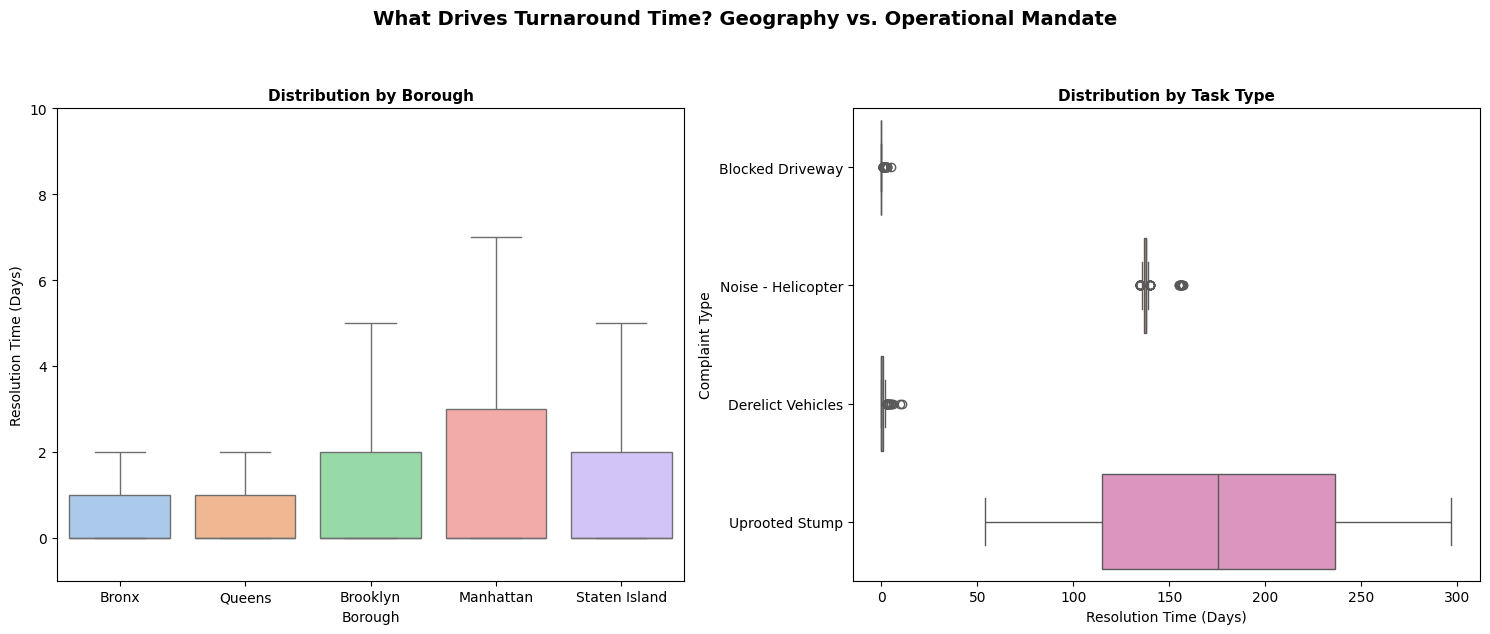

In [ ]:
import seaborn as sns 


# 1
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(
    x="Borough", 
    y="Resolution_Days", 
    data=df, 
    ax=axes[0], 
    palette="pastel",
    showfliers=False

)
axes[0].set_title("Distribution by Borough", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Borough", fontsize=10)
axes[0].set_ylabel("Resolution Time (Days)", fontsize=10)
axes[0].set_ylim(-1, 10)

# 2

target_complaints = [
    "Uprooted Stump", 
    "Noise - Helicopter", 
    "Derelict Vehicles", 
    "Blocked Driveway"
]


df_filtered = df[df["Complaint_Type"].isin(target_complaints)]

sns.boxplot(
    y="Complaint_Type", 
    x="Resolution_Days", 
    data=df_filtered, 
    ax=axes[1], 
    palette="Set2",
    showfliers=True 
)
axes[1].set_title("Distribution by Task Type", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Resolution Time (Days)", fontsize=10)
axes[1].set_ylabel("Complaint Type", fontsize=10)


plt.suptitle("What Drives Turnaround Time? Geography vs. Operational Mandate", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()